# Pandas

`pandas` es un módulo que extiende el ndarray de numpy para permitir una estructura de datos que etiqueta las columnas. Tiene dos clases principales, que son:
- `Series`: una estructura unidimensional que puede contener cualquier tipo de datos.
- `DataFrame`: una estructura bidimensional que puede contener diferentes tipos de datos en columnas.

El módulo nos permite operar como lo haríamos con una hoja de cálculo, donde el `dataframe` sería la tabla con los datos.

Pandas nos ofrece gran funcionalidad para análisis de datos, tales como:
- Lectura de datos desde diferentes formatos (CSV, Excel, SQL, etc.)
- Manipulación y limpieza de datos
- Análisis estadístico
- Visualización de datos (junto con matplotlib)


La documentación oficial para profundizar está aquí:

http://pandas.pydata.org/pandas-docs/stable/dsintro.html#dsintro

Pandas se importa normalmente con el alias `pd`:


In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Serie

Una serie es un arreglo etiquetado. Superficialmente parece un diccionario, pero tiene un tamaño fijo y puede manejar valores faltantes. También puede ser operado con cualquier operación numpy o los operadores estándar (un diccionario no puede). Las etiquetas se conocen como el _índice_.

Algunos ejemplos de: http://pandas.pydata.org/pandas-docs/stable/dsintro.html

In [353]:
s = pd.Series(np.random.randn(5), index=['a', 'b', 'c', 'd', 'e'])
s

a   -0.089440
b    0.610760
c   -0.917671
d   -0.196884
e   -0.064789
dtype: float64

In [354]:
s.index

Index(['a', 'b', 'c', 'd', 'e'], dtype='object')

Si no especificas un índice, se creará uno automáticamente del 0 al n-1.

In [355]:
pd.Series(np.random.randn(5))

0   -0.189927
1   -0.367329
2   -0.273935
3    1.108309
4   -0.566942
dtype: float64

Puedes inicializar desde un diccionario. Por defecto usará las claves del diccionario (ordenadas) como el índice

In [356]:
d = {'a' : 0., 'b' : 1., 'c' : 2.}
pd.Series(d)

a    0.0
b    1.0
c    2.0
dtype: float64

In [357]:
pd.Series(d, index=['b', 'c', 'd', 'a'])

b    1.0
c    2.0
d    NaN
a    0.0
dtype: float64

Ten en cuenta que NaN indica un valor faltante

Puedes operar sobre una serie como lo harías con cualquier ndarray

In [358]:
s

a   -0.089440
b    0.610760
c   -0.917671
d   -0.196884
e   -0.064789
dtype: float64

In [359]:
s[0]

/var/folders/qw/g5bf4m1n2pd5cw5q06tjd3xw0000gn/T/ipykernel_83813/243613605.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  s[0]


np.float64(-0.0894399936381761)

In [360]:
s[:3]

a   -0.089440
b    0.610760
c   -0.917671
dtype: float64

In [361]:
s[s > s.median()]

b    0.610760
e   -0.064789
dtype: float64

In [362]:
np.exp(s)

a    0.914443
b    1.841831
c    0.399448
d    0.821286
e    0.937265
dtype: float64

También puedes indexar por etiqueta -- esto imita el comportamiento de un diccionario

In [363]:
s['a']

np.float64(-0.0894399936381761)

In [364]:
s['e']

np.float64(-0.06478910061731658)

In [365]:
'e' in s

True

El método `get()` se puede usar para acceder de forma segura a un elemento si es posible que no exista -- puedes especificar un valor por defecto a retornar en ese caso. La alternativa es usar un bloque `try` / `except`.

In [366]:
s.get('f', np.nan)

nan

Las operaciones, como las que usas con un ndarray funcionan bien en una Serie

In [367]:
s + s

a   -0.178880
b    1.221520
c   -1.835343
d   -0.393767
e   -0.129578
dtype: float64

In [368]:
s * 2

a   -0.178880
b    1.221520
c   -1.835343
d   -0.393767
e   -0.129578
dtype: float64

Ten en cuenta que las operaciones siempre se hacen sobre etiquetas coincidentes, así que lo siguiente no es exactamente lo mismo que los arrays de numpy. Aquí s[1:] contendrá 4 valores con los índices 1, 2, 3, 4, mientras que s[:-1] contendrá 4 valores con los índices 0, 1, 2, 3. La suma se hace sobre las etiquetas coincidentes (1, 2, 3), y los otros índices resultan en NaN porque no tienen coincidencia. En este sentido, pandas respeta la unión de índices.

In [369]:
s[1:] + s[:-1]

a         NaN
b    1.221520
c   -1.835343
d   -0.393767
e         NaN
dtype: float64

## DataFrame

El dataframe es la estuctura básica de pandas, es como una hoja de cálculo -- las columnas y filas tienen etiquetas. Es bidimensional. 

Puedes inicializar desde:
  * Diccionario de ndarrays 1-D, listas, diccionarios, o Series
  * numpy.ndarray 2-D
  * ndarray estructurado (matriz o array)
  * Una Serie
  * Otro DataFrame

De forma general, creamos un dataframe así:

```python
df = pd.DataFrame(data, columns=column_names, index=row_names)
```

Si no le pasamos una lista con los nombres de las columnas, se crearán automáticamente como 0, 1, 2, ... Si no le pasamos una lista con los nombres de las filas, se crearán automáticamente como 0, 1, 2, ...

Algunos ejemplos:

In [370]:
d = {'one' : pd.Series([1., 2., 3.], index=['b', 'a', 'c']),
     'two' : pd.Series([2, 1., 3., 4.], index=['b', 'a', 'c', 'd']),
     'four' : pd.Series([5, 6, 7., 8.], index=['a', 'b', 'c', 'd']),
     'names' : pd.Series(["John", "Mary", "Marvel", "Thor"], index=['a', 'b', 'c', 'd'])}

In [371]:
df = pd.DataFrame(d)
df

,one,two,four,names
a,2.0,1.0,5.0,John
b,1.0,2.0,6.0,Mary
c,3.0,3.0,7.0,Marvel
d,NaN,4.0,8.0,Thor


Podemos crear un dataframe a partir de otro, excluyendo algunas columnas. 

In [372]:
pd.DataFrame(d, index=['d', 'b', 'a'])

,one,two,four,names
d,NaN,4.0,8.0,Thor
b,1.0,2.0,6.0,Mary
a,2.0,1.0,5.0,John


Aquí está la inicialización desde listas / ndarrays

In [373]:
d = {'one' : [1., 2., 3., 4.],
     'two' : [4., 3., 2., 1.]}

In [374]:
pd.DataFrame(d)

,one,two
0,1.0,4.0
1,2.0,3.0
2,3.0,2.0
3,4.0,1.0


In [375]:
pd.DataFrame(d, index=['a', 'b', 'c', 'd'])

,one,two
a,1.0,4.0
b,2.0,3.0
c,3.0,2.0
d,4.0,1.0


Hay muchos otros métodos de inicialización, p.ej., lista de diccionarios

In [376]:
data2 = [{'a': 1, 'b': 2}, {'a': 5, 'b': 10, 'c': 20}]
pd.DataFrame(data2, index=['first', 'second'])

,a,b,c
first,1,2,NaN
second,5,10,20.0


### CSV

También puedes leer desde CSV

Nota: si hay espacios en blanco extraños en tus cadenas en el CSV, pandas los mantendrá. Esto es un poco molesto y es posible que necesites investigar convertidores para que las cosas estén adecuadamente formateadas.

El método general es:

```python
pd.read_csv('file_name.csv', index_col='column_name', rownames=['row1', 'row2', ...], sep='simbolo', header=none or int,...)
```

Hay métodos similares para Excel (pd.read_excel) y SQL (pd.read_sql). POr ejemplo, para Excel:

```python
pd.read_excel('file_name.xlsx', sheet_name='Sheet1', index_col='column_name', ...)
```

Consulta la documentación para más detalles.

### Acceso a DataFrames
Pandas proporciona métodos optimizados para acceder a datos: .at, .iat, .loc, .iloc, y .ix. También puedes indexarlo como si fueran objetos Series. Algunos accesos son los siguientes:

  * Seleccionar columna: `df[col]` (retorna Series)
  * Seleccionar fila por etiqueta: `df.loc[label]` (retorna Series)
  * Seleccionar fila por ubicación de entero: `df.iloc[loc]` (retorna Series)
  * Dividir en slices filas: `df[5:10]` (retorna DataFrame)
  * Seleccionar por etiqueta: `df.at[row_label, col_label]` (retorna valor escalar)
  * Seleccionar por ubicación de entero: `df.iat[row_loc, col_loc]` (retorna valor escalar)
  * Seleccionar por etiqueta: `df.loc[row_labels, col_labels]` (retorna DataFrame o Series)
  * Seleccionar por ubicación de entero: `df.iloc[row_locs, col_locs]` (retorna DataFrame o Series)
  * Seleccionar por etiqueta o ubicación de entero: `df.ix[row_selection, col_selection]` (retorna DataFrame o Series) -- **DEPRECATED**, no usar en nuevo código.
  * Seleccionar filas por condición: `df[df['col'] > value]` (retorna DataFrame)



```{admonition} Nota
:class: important
El uso de los [] para seleccionar filas y columnas es a veces confuso en pandas. Si usas `df["etiqueta"]` se refiere a una columna, no a una fila. Si pones un número dentro de los corchetes, pandas buscará una columna con ese nombre, no una fila por posición. No obstante, si usas slicing como `df[0:3]`, pandas interpretará que quieres las filas en esas posiciones. Si quieres seleccionar varias columnas, debes pasar una lista de nombres de columnas, como `df[["col1", "col2"]]`. Para evitar esta confusión, es recomendable usar los métodos `.loc` y `.iloc`.
```

Veamos algunos ejemplos de indexado solo usando corchetes:

In [381]:
df

,one,two,four,names
a,2.0,1.0,5.0,John
b,1.0,2.0,6.0,Mary
c,3.0,3.0,7.0,Marvel
d,NaN,4.0,8.0,Thor


In [382]:
df['one']

a    2.0
b    1.0
c    3.0
d    NaN
Name: one, dtype: float64

Para comprobar de qué tipo es lo que hemos seleccionado, podemos usar `type()`:

In [383]:
type(df['one'])

pandas.core.series.Series

```{admonition} Nota
:class: note
El uso de los [] para seleccionar filas y columnas es **diferente** al uso de los métodos `.loc` y `.iloc`. En particular, cuando se usan los corchetes `[]` o `.loc` para hacer slicing de filas, el extremo final está **incluido**, al ser etiquetas y no posiciones, mientras que con `.iloc` el extremo final está **excluido** (como en NumPy, porque son posiciones).
```

In [384]:
df["a":"c"]

,one,two,four,names
a,2.0,1.0,5.0,John
b,1.0,2.0,6.0,Mary
c,3.0,3.0,7.0,Marvel


Veamos algunos ejemplos de indexado ahora con los métodos `.loc`, `.iloc`, `iat` y `at`:

In [385]:
df.loc[:,[ "names", "two"]]

,names,two
a,John,1.0
b,Mary,2.0
c,Marvel,3.0
d,Thor,4.0


`at` es un método de acceso más rápido

In [386]:
df.at["a","one"]

np.float64(2.0)

Las rutinas `i` funcionan en el espacio de índices, similar a cómo lo hace numpy

In [387]:
df.iloc[1:3,0:2]

,one,two
b,1.0,2.0
c,3.0,3.0


In [388]:
df.iloc[[1,3], [0,1,3]]

,one,two,names
b,1.0,2.0,Mary
d,NaN,4.0,Thor


In [389]:
df.iat[2,2]

np.float64(7.0)

También puedes tratar cualquier nombre de índice como si fuera una propiedad

In [390]:
df.four

a    5.0
b    6.0
c    7.0
d    8.0
Name: four, dtype: float64

### Indexado booleano

Igual que ocurría en NumPy, podemos usar indexado booleano para seleccionar filas que cumplan una condición. También podemos seleccionar columnas de forma similar.
```
# Acceder a la columna "three" de df cuyas filas cumplen una condición

```

In [391]:
df[df.two > 3]

,one,two,four,names
d,NaN,4.0,8.0,Thor


In [392]:
df[df['one'] > 0]['four']

# Equivalente a la línea anterior pero usando loc
df.loc[df['one'] > 0, 'four']

a    5.0
b    6.0
c    7.0
Name: four, dtype: float64

### Modificación de DataFrames

Pandas permite modificar DataFrames de varias maneras, incluyendo la adición, eliminación y actualización de filas y columnas. Como ocurre en otro tipo de clases en Python, podemos modificar valores ya existentes accediendo a ellos y asignándoles nuevos valores.

In [431]:
df.loc["d","one"]= 6
df.loc[df['one'] >= 2, ['four', 'names']]= [4, 'person']
df

,one,four,names,flag,foo
a,2.0,4.0,person,False,bar
b,1.0,6.0,Mary,False,bar
c,3.0,4.0,person,True,bar
d,6.0,4.0,person,False,bar


Podemos añadir columnas nuevas simplemente asignándoles valores:

In [394]:
df['three'] = df['one'] * df['two']
df['flag'] = df['one'] > 2
df

,one,two,four,names,three,flag
a,2.0,1.0,4.0,person,2.0,False
b,1.0,2.0,6.0,Mary,2.0,False
c,3.0,3.0,4.0,person,9.0,True
d,NaN,4.0,8.0,Thor,NaN,False


Puedes eliminar o hacer pop de columnas, igual que en otros objetos en Python. Hacer pop retorna una `Series`, la que quieres eliminar.

In [395]:
del df['two']

In [396]:
three = df.pop('three')

In [397]:
df

,one,four,names,flag
a,2.0,4.0,person,False
b,1.0,6.0,Mary,False
c,3.0,4.0,person,True
d,NaN,8.0,Thor,False


In [398]:
three

a    2.0
b    2.0
c    9.0
d    NaN
Name: three, dtype: float64

Podemos añadir filas nuevas usando el método `loc`:


In [ ]:
df.loc['e'] = [7, 8, 9, 10, 'new_person']
df

Podemos eliminar una fila usando el método `drop`:

In [ ]:
df = df.drop('e')
df

## Un ejemplo completo

A continuación, vamos a utilizar pandas para analizar un conjunto de datos que hemos leído en el fichero samples.csv. Este fichero contiene una serie de calificaciones de estudiantes en varias tareas (homework) y en el examen de una asignatura. Vamos a realizar algunas operaciones básicas de análisis de datos utilizando pandas.

Lo primero, vamos a guardar el contenido del fichero samples.csv en un DataFrame llamado `grades`.

In [ ]:
grades = pd.read_csv('sample.csv', index_col="student", skipinitialspace=True)

In [ ]:
grades

,hw 1,hw 2,hw 3,hw 4,exam
student,,,,,
A,10.0,9.0,10,7,97
B,8.0,7.0,9,9,82
C,NaN,9.0,6,5,75
D,8.0,9.0,9,9,90
E,NaN,10.0,10,10,95
F,8.0,2.0,6,7,66
G,6.0,NaN,4,5,60
H,8.0,8.0,9,8,84
I,10.0,7.0,10,10,92


In [ ]:
grades.index

Index(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N',
       'O', 'P', 'Q'],
      dtype='object', name='student')

In [ ]:
grades.columns

Index(['hw 1', 'hw 2', 'hw 3', 'hw 4', 'exam'], dtype='object')

Las calificaciones de un solo estudiante

In [401]:
grades.loc["A"]

hw 1    10.0
hw 2     9.0
hw 3    10.0
hw 4     7.0
exam    97.0
Name: A, dtype: float64

Todas las calificaciones de la primera tarea

In [402]:
grades['hw 1']

student
A    10.0
B     8.0
C     NaN
D     8.0
E     NaN
F     8.0
G     6.0
H     8.0
I    10.0
J    10.0
K     8.0
L     3.0
M     9.0
N     8.0
O    10.0
P     8.0
Q     5.0
Name: hw 1, dtype: float64

Crear una nueva columna basada en las existentes

In [403]:
grades['hw average'] = (grades['hw 1'] + grades['hw 2'] + grades['hw 3'] + grades['hw 4'])/4.0

In [404]:
grades

,hw 1,hw 2,hw 3,hw 4,exam,hw average
student,,,,,,
A,10.0,9.0,10,7,97,9.00
B,8.0,7.0,9,9,82,8.25
C,NaN,9.0,6,5,75,NaN
D,8.0,9.0,9,9,90,8.75
E,NaN,10.0,10,10,95,NaN
F,8.0,2.0,6,7,66,5.75
G,6.0,NaN,4,5,60,NaN
H,8.0,8.0,9,8,84,8.25
I,10.0,7.0,10,10,92,9.25


Esto no manejó adecuadamente los datos faltantes (NaN). Para arreglarlo, vamos a sustituir los NaNs con 0

In [405]:
g2 = grades.fillna(0)

In [406]:
g2['hw average'] = (g2['hw 1'] + g2['hw 2'] + g2['hw 3'] + g2['hw 4'])/4.0

In [407]:
g2

,hw 1,hw 2,hw 3,hw 4,exam,hw average
student,,,,,,
A,10.0,9.0,10,7,97,9.00
B,8.0,7.0,9,9,82,8.25
C,0.0,9.0,6,5,75,5.00
D,8.0,9.0,9,9,90,8.75
E,0.0,10.0,10,10,95,7.50
F,8.0,2.0,6,7,66,5.75
G,6.0,0.0,4,5,60,3.75
H,8.0,8.0,9,8,84,8.25
I,10.0,7.0,10,10,92,9.25


Para dataframes grandes, podemos ver solo partes

In [408]:
g2.head()

,hw 1,hw 2,hw 3,hw 4,exam,hw average
student,,,,,,
A,10.0,9.0,10,7,97,9.00
B,8.0,7.0,9,9,82,8.25
C,0.0,9.0,6,5,75,5.00
D,8.0,9.0,9,9,90,8.75
E,0.0,10.0,10,10,95,7.50


In [409]:
g2.tail(2)

,hw 1,hw 2,hw 3,hw 4,exam,hw average
student,,,,,,
P,8.0,9.0,8,10,94,8.75
Q,5.0,7.0,6,5,78,5.75


### Estadísticas

Podemos obtener estadísticas descriptivas básicas de las columnas numéricas usando el método `describe()`:

In [410]:
g2.describe()

,hw 1,hw 2,hw 3,hw 4,exam,hw average
count,17.000000,17.000000,17.000000,17.000000,17.000000,17.000000
mean,7.000000,7.470588,7.882353,8.000000,85.000000,7.588235
std,3.221025,2.741296,1.964763,1.732051,11.407235,1.747635
min,0.000000,0.000000,4.000000,5.000000,60.000000,3.750000
25%,6.000000,7.000000,6.000000,7.000000,78.000000,5.750000
50%,8.000000,8.000000,9.000000,9.000000,90.000000,8.250000
75%,9.000000,9.000000,9.000000,9.000000,94.000000,8.750000
max,10.000000,10.000000,10.000000,10.000000,99.000000,9.750000


¿Quieres ordenar por valores? Tenemos el método `sort_values`.

In [411]:
g2.sort_values(by="exam")

,hw 1,hw 2,hw 3,hw 4,exam,hw average
student,,,,,,
G,6.0,0.0,4,5,60,3.75
F,8.0,2.0,6,7,66,5.75
L,3.0,8.0,5,7,71,5.75
C,0.0,9.0,6,5,75,5.00
Q,5.0,7.0,6,5,78,5.75
B,8.0,7.0,9,9,82,8.25
H,8.0,8.0,9,8,84,8.25
K,8.0,7.0,6,8,87,7.25
N,8.0,10.0,9,9,90,9.00


Podemos calcular algunos estadísticos básicos directamente:

In [412]:
g2.mean()

hw 1           7.000000
hw 2           7.470588
hw 3           7.882353
hw 4           8.000000
exam          85.000000
hw average     7.588235
dtype: float64

In [413]:
g2.median()

hw 1           8.00
hw 2           8.00
hw 3           9.00
hw 4           9.00
exam          90.00
hw average     8.25
dtype: float64

In [414]:
g2.max()

hw 1          10.00
hw 2          10.00
hw 3          10.00
hw 4          10.00
exam          99.00
hw average     9.75
dtype: float64

Se puede aplicar una función al `DataFrame` utilizando el método `.apply()`. Por defecto, funcionará sobre índices (p.ej., aplicando tu función en una columna), tratando las entradas como una `Series`.

En el ejemplo siguiente, `x` sería cada columna de la tabla (una Series). Calcula el máximo y el mínimo de esa columna, lo resta y nos devuelve un escalar. Finalmente, debe devolvernos una columna con el resultado de cada columna.

Si quieres aplicar la función por filas, puedes usar `axis=1`.

In [416]:
g2.apply(lambda x: x.max() - x.min())

hw 1          10.0
hw 2          10.0
hw 3           6.0
hw 4           5.0
exam          39.0
hw average     6.0
dtype: float64

In [432]:
g2.apply(lambda x: x.mean(), axis=1)

student
A    20.329943
B    17.697124
C    15.085157
D    19.154577
E    19.057619
F    15.569187
G    14.203617
H    17.979057
I    19.776265
J    19.174601
K    17.719238
L    15.644091
M    19.785745
N    19.387850
O    21.217568
P    19.692698
Q    15.566631
R     1.000000
dtype: float64

### Arrays de np

In [417]:
g2.loc[:, "new"] = np.random.random(len(g2))

In [418]:
g2

,hw 1,hw 2,hw 3,hw 4,exam,hw average,new
student,,,,,,,
A,10.0,9.0,10,7,97,9.00,0.309602
B,8.0,7.0,9,9,82,8.25,0.629867
C,0.0,9.0,6,5,75,5.00,0.596101
D,8.0,9.0,9,9,90,8.75,0.332036
E,0.0,10.0,10,10,95,7.50,0.903336
F,8.0,2.0,6,7,66,5.75,0.234308
G,6.0,0.0,4,5,60,3.75,0.675317
H,8.0,8.0,9,8,84,8.25,0.603400
I,10.0,7.0,10,10,92,9.25,0.183856


Podemos actualizar múltiples valores a la vez usando `.loc` y recogiendo los valores de los índices que cumplan alguna condición utilizando `.index`:

In [419]:
a = g2[g2.exam < 80].index

In [420]:
a

Index(['C', 'F', 'G', 'L', 'Q'], dtype='object', name='student')

In [421]:
g2.loc[a, "exam"] = 80

In [422]:
g2

,hw 1,hw 2,hw 3,hw 4,exam,hw average,new
student,,,,,,,
A,10.0,9.0,10,7,97,9.00,0.309602
B,8.0,7.0,9,9,82,8.25,0.629867
C,0.0,9.0,6,5,80,5.00,0.596101
D,8.0,9.0,9,9,90,8.75,0.332036
E,0.0,10.0,10,10,95,7.50,0.903336
F,8.0,2.0,6,7,80,5.75,0.234308
G,6.0,0.0,4,5,80,3.75,0.675317
H,8.0,8.0,9,8,84,8.25,0.603400
I,10.0,7.0,10,10,92,9.25,0.183856


## Gráficas

Al igual que matplotlib, pandas tiene capacidades de graficación integradas. Podemos crear gráficos directamente desde DataFrames y Series utilizando el método `.plot()`. 

In [424]:
%matplotlib inline

<Axes: xlabel='student'>

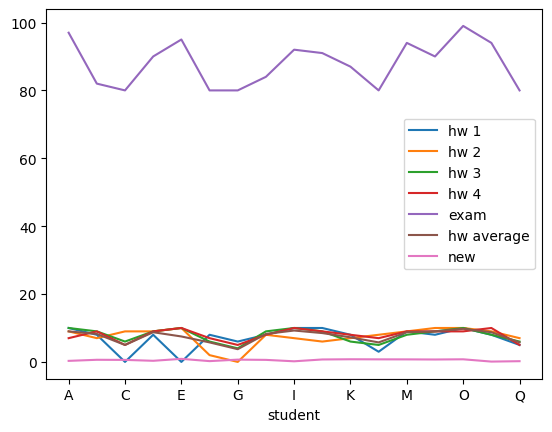

In [425]:
g2.plot()

<Axes: xlabel='hw average', ylabel='exam'>

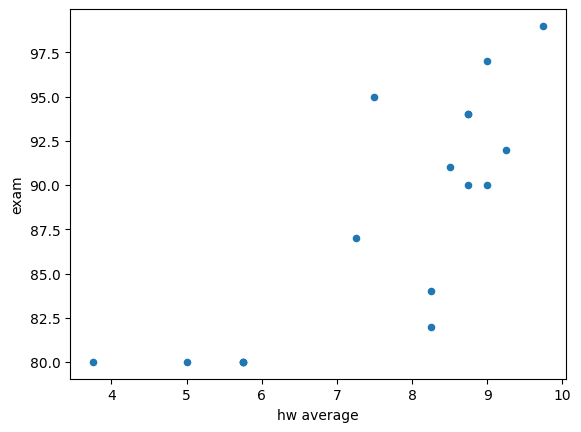

In [426]:
g2.plot.scatter(x="hw average", y="exam", marker="o")

Hay muchos más ejemplos en: http://pandas.pydata.org/pandas-docs/stable/visualization.html. No obstante, en este curso utilizaremos matplotlib para crear gráficos más complejos.

Podemos pasar una tabla a diferentes formatos o guardarlo en un fichero. Por ejemplo:

In [430]:
g2.to_latex()

'\\begin{tabular}{lrrrrrrr}\n\\toprule\n & hw 1 & hw 2 & hw 3 & hw 4 & exam & hw average & new \\\\\nstudent &  &  &  &  &  &  &  \\\\\n\\midrule\nA & 10.000000 & 9.000000 & 10.000000 & 7.000000 & 97.000000 & 9.000000 & 0.309602 \\\\\nB & 8.000000 & 7.000000 & 9.000000 & 9.000000 & 82.000000 & 8.250000 & 0.629867 \\\\\nC & 0.000000 & 9.000000 & 6.000000 & 5.000000 & 80.000000 & 5.000000 & 0.596101 \\\\\nD & 8.000000 & 9.000000 & 9.000000 & 9.000000 & 90.000000 & 8.750000 & 0.332036 \\\\\nE & 0.000000 & 10.000000 & 10.000000 & 10.000000 & 95.000000 & 7.500000 & 0.903336 \\\\\nF & 8.000000 & 2.000000 & 6.000000 & 7.000000 & 80.000000 & 5.750000 & 0.234308 \\\\\nG & 6.000000 & 0.000000 & 4.000000 & 5.000000 & 80.000000 & 3.750000 & 0.675317 \\\\\nH & 8.000000 & 8.000000 & 9.000000 & 8.000000 & 84.000000 & 8.250000 & 0.603400 \\\\\nI & 10.000000 & 7.000000 & 10.000000 & 10.000000 & 92.000000 & 9.250000 & 0.183856 \\\\\nJ & 10.000000 & 6.000000 & 9.000000 & 9.000000 & 91.000000 & 8.500000 &

Para guardar el `DataFrame`en un fichero, podemos utilizar los métodos `to_csv()`o `to_excel()`. Por ejemplo: 

```python
g2.to_csv('students.csv', index=False, header=False, sep='simbolo') #Guarda sin índices, sin cabecera y con separador 'simbolo'
g2.to_excel('output.xlsx', index=False)  # Guarda sin índices pero sí la cabecera.
```